# Calculate geometric mean of coverages

In [1]:
import polars as pl
import seaborn as sns

In [2]:
cov_df = pl.read_csv('../outputs.cds/kmer-coverage.csv')

In [3]:
cov_df = cov_df.select(['species', 'metag', 'depth'])
cov_df

species,metag,depth
str,str,f64
"""s__Cryptobacteroides sp0004326…","""SRR11125436""",0.277108
"""s__Bariatricus sp004560705""","""SRR11125436""",0.651935
"""s__Floccifex porci""","""SRR11125436""",0.254813
"""s__Cryptobacteroides sp0340892…","""SRR11125436""",0.547788
"""s__Prevotella sp000434975""","""SRR11125436""",0.009389
…,…,…
"""s__Colivicinus sp002299675""","""ERR8314784""",2.321568
"""s__CAG-269 sp014846485""","""ERR8314784""",0.00441
"""s__UMGS1225 sp034086705""","""ERR8314784""",0.075952


In [4]:
# fill in nulls
metag_df = cov_df.select(['metag']).unique()
species_df = cov_df.select(['species']).unique()
cross_df = metag_df.join(species_df, how='cross')
cov_df = cov_df.join(cross_df, on=['metag', 'species'], how='right').with_columns(
    pl.col("depth").fill_null(.00001)
)
cov_df

depth,metag,species
f64,str,str
0.00001,"""SRR11126532""","""s__SIG351 sp945918795"""
0.562639,"""SRR11126532""","""s__Lactobacillus amylovorus"""
0.117655,"""SRR11126532""","""s__Colivicinus sp002299675"""
0.001663,"""SRR11126532""","""s__CAG-873 sp016302215"""
2.765944,"""SRR11126532""","""s__Sodaliphilus sp004557565"""
…,…,…
0.00001,"""SRR11126245""","""s__CAG-269 sp014846485"""
0.05406,"""SRR11126245""","""s__Fimisoma sp002320005"""
0.023076,"""SRR11126245""","""s__UBA2868 sp004552595"""


In [5]:
# note, zeros not handled
geo_df = cov_df.group_by('metag').agg(pl.col('depth').log().mean().exp().alias("global_geomean"))
geo2_df = cov_df.group_by('species').agg(pl.col('depth').log().mean().exp().alias("species_geomean"))
geo3_df = geo_df.join(geo2_df, how='cross')

In [6]:
join_df = cov_df.join(geo3_df, on=['metag', 'species'], how='inner').with_columns(
    global_logdiff=(pl.col("depth").log(base=2) - pl.col("global_geomean").log(base=2)),
    species_logdiff=(pl.col("depth").log(base=2) - pl.col("species_geomean").log(base=2))
)

In [7]:
order_xx = geo2_df.sort(by='species_geomean', descending=True)['species'].to_list()

<Axes: xlabel='global_logdiff', ylabel='species'>

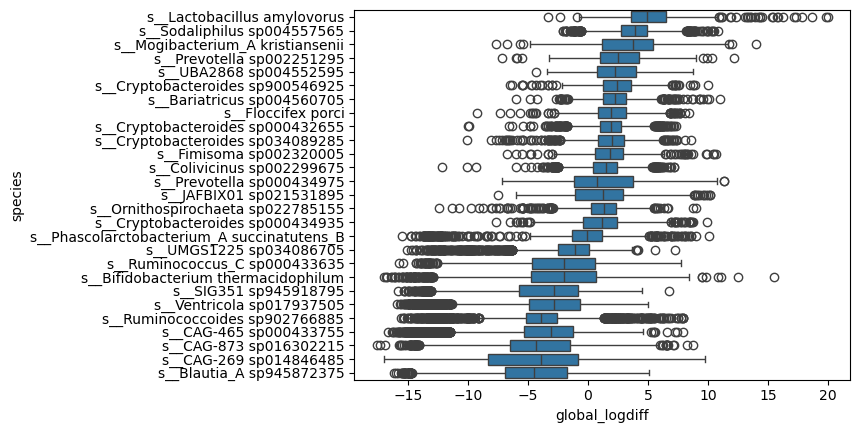

In [8]:
sns.boxplot(x='global_logdiff', y='species', data=join_df, order=order_xx)

<Axes: xlabel='global_logdiff', ylabel='species'>

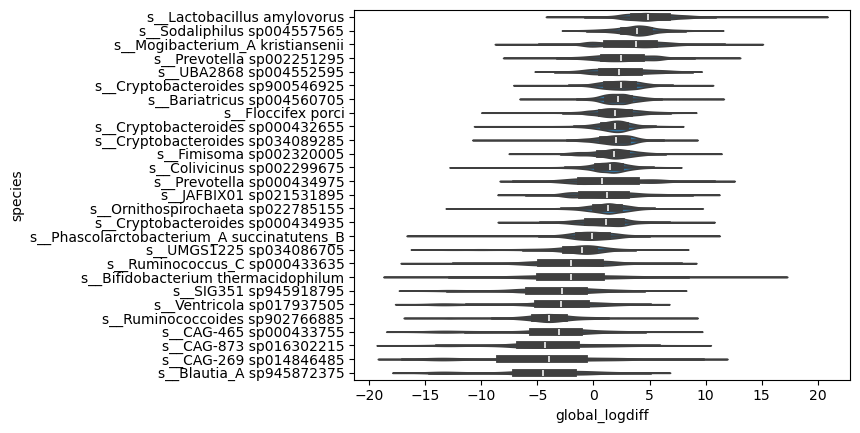

In [9]:
sns.violinplot(x='global_logdiff', y='species', data=join_df, order=order_xx)

In [10]:
with pl.Config(tbl_rows=-1):
    xx_df = join_df.filter(pl.col("species") == 's__Lactobacillus amylovorus').sort(by='species_logdiff', descending=True).head(100)
    print(xx_df.select(['depth', 'species_logdiff']))

shape: (100, 2)
┌────────────┬─────────────────┐
│ depth      ┆ species_logdiff │
│ ---        ┆ ---             │
│ f64        ┆ f64             │
╞════════════╪═════════════════╡
│ 794.589559 ┆ 6.879983        │
│ 754.374399 ┆ 6.805054        │
│ 735.06344  ┆ 6.767642        │
│ 735.022865 ┆ 6.767563        │
│ 690.587913 ┆ 6.677599        │
│ 689.37878  ┆ 6.67507         │
│ 605.177698 ┆ 6.487132        │
│ 604.777359 ┆ 6.486178        │
│ 593.57868  ┆ 6.459213        │
│ 580.508144 ┆ 6.42709         │
│ 572.238975 ┆ 6.406391        │
│ 460.341449 ┆ 6.092478        │
│ 452.475324 ┆ 6.067613        │
│ 439.331753 ┆ 6.025084        │
│ 403.59336  ┆ 5.902676        │
│ 402.373407 ┆ 5.898308        │
│ 400.431221 ┆ 5.891328        │
│ 399.284303 ┆ 5.88719         │
│ 357.484016 ┆ 5.727652        │
│ 354.411142 ┆ 5.715197        │
│ 340.569683 ┆ 5.657724        │
│ 335.454537 ┆ 5.635891        │
│ 317.179592 ┆ 5.555073        │
│ 316.365388 ┆ 5.551365        │
│ 316.254483 ┆ 5.550859    